In [1]:
import numpy as np

In [7]:

def adjacent_matrix(x):
    edges=[]
    max_nodes_id=0
    with open(x,"r") as file:
        for line in file:
            clean_line=line.strip()
            if not clean_line or clean_line.startswith("#"):
                continue
            node_a,node_b=map(int,clean_line.split())
            edges.append((node_a,node_b))
            if node_a>max_nodes_id:max_nodes_id=node_a
            if node_b>max_nodes_id:max_nodes_id=node_b
        matrix_size=max_nodes_id+1
        adjacency_matrix=np.zeros((matrix_size,matrix_size),dtype=int)
        for u,v in edges:
            adjacency_matrix[u,v]=1
            adjacency_matrix[v,u]=1
    return adjacency_matrix
fine_name="adjacentmatrix.txt"
x = "facebook_combined.txt"
try:
        matrix= adjacent_matrix(x)    
        print(matrix)
except FileNotFoundError:
        print("could not found file")        



[[0 1 1 ... 0 0 0]
 [1 0 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [12]:
!pip install networkx
!pip install scipy
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np


  Using cached scipy-1.15.3-cp310-cp310-macosx_14_0_arm64.whl.metadata (61 kB)
Using cached scipy-1.15.3-cp310-cp310-macosx_14_0_arm64.whl (22.4 MB)


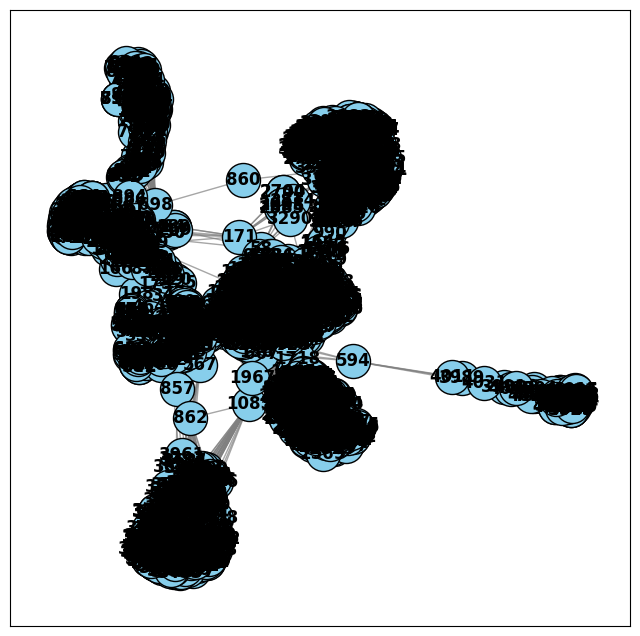

In [13]:
matrix=np.array(matrix)
G=nx.from_numpy_array(matrix)
plt.figure(figsize=(8,8))
pos=nx.spring_layout(G,seed=42)
nx.draw_networkx_nodes(
    G,pos,node_color="skyblue",node_size=600,edgecolors="black")
nx.draw_networkx_edges(G,pos,node_size=600,edge_color="grey",alpha=0.7)
nx.draw_networkx_labels(G,pos,font_size=12,font_weight="bold")
plt.show()    



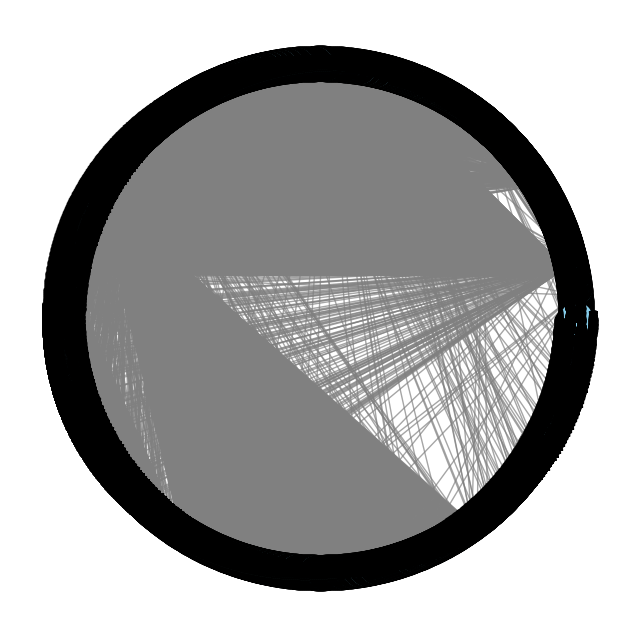

In [14]:
matrix = np.array(matrix)
G = nx.from_numpy_array(matrix)

plt.figure(figsize=(8, 8))

# Circular positioning doesn't rely on external math packages
pos = nx.circular_layout(G)

# Render structural elements
nx.draw_networkx_nodes(
    G, pos, node_color="skyblue", node_size=600, edgecolors="black"
)
nx.draw_networkx_edges(G, pos, edge_color="grey", alpha=0.7)
nx.draw_networkx_labels(G, pos, font_size=12, font_weight="bold")

plt.axis("off")
plt.show()

In [15]:
from collections import deque 
import numpy as np


In [24]:
def matrix_graph_distance(adj_matrix,start_node,target_node):
    if start_node==target_node:
        return 0
    num_nodes=adj_matrix.shape[0]
    visited=[False]*num_nodes
    queue=deque([(start_node,0)]) 
    visited[start_node]=True
    while queue:
        current,dist=queue.popleft()
        if current==target_node:
            return dist
        neighbors=np.where(adj_matrix[current]==1)[0]
        for neighbor in neighbors:
            if not visited[neighbor]:
                visited[neighbor]=True
                queue.append((neighbor,dist+1))
    return -1                   

In [26]:
matrix_graph_distance(matrix,0,4037)

5

In [22]:



def analyze_entire_network(adj_matrix):
    num_nodes = adj_matrix.shape[0]

    # Global tracking variables
    all_distances = []
    connected_components_sizes = []
    visited_globally = np.zeros(num_nodes, dtype=bool)

    print("Analyzing network structure... This might take a moment.")

    # Loop through every node to find separate sub-graphs (components)
    for root in range(num_nodes):
        if visited_globally[root]:
            continue

        # We found a new separate network component! Let's map it.
        component_nodes = []
        queue = deque([(root, 0)])
        visited_globally[root] = True

        # Run a complete BFS from this root node
        while queue:
            current, dist = queue.popleft()
            component_nodes.append(current)

            # Record every valid distance found from this root
            if dist > 0:
                all_distances.append(dist)

            neighbors = np.where(adj_matrix[current] == 1)[0]
            for neighbor in neighbors:
                if not visited_globally[neighbor]:
                    visited_globally[neighbor] = True
                    queue.append((neighbor, dist + 1))

        # Save the size of this isolated group
        connected_components_sizes.append(len(component_nodes))

    # --- Compute Global Network Statistics ---
    total_components = len(connected_components_sizes)

    if len(all_distances) > 0:
        max_distance = max(all_distances)
        avg_distance = sum(all_distances) / len(all_distances)
    else:
        max_distance = 0
        avg_distance = 0

    # Sort component sizes from largest to smallest
    connected_components_sizes.sort(reverse=True)

    # --- Print a Comprehensive Backend Report ---
    print("\n================ SYSTEM ANALYSIS REPORT ================")
    print(f"Total Unique Nodes in Matrix: {num_nodes}")
    print(f"Isolated Graph Components Discovered: {total_components}")
    print(f"Largest Connected Group Size: {connected_components_sizes[0]} nodes")

    if total_components > 1:
        print(
            f"⚠️ Warning: The network is fractured into {total_components} separate sub-graphs."
        )
        print(f"Sizes of smaller isolated groups: {connected_components_sizes[1:]}")
        print(
            "-> Any path crossing between these distinct groups will return -1."
        )
    else:
        print("✅ Success: Every single node is connected to the same network.")

    print("--------------------------------------------------------")
    print(f"Maximum Path Distance (Graph Diameter): {max_distance} steps")
    print(f"Average Path Distance between connected nodes: {avg_distance:.2f} steps")
    print("========================================================")


# --- Run it on your loaded matrix ---
# analyze_entire_network(matrix)

In [23]:
analyze_entire_network(matrix)

Analyzing network structure... This might take a moment.

================ SYSTEM ANALYSIS REPORT ================
Total Unique Nodes in Matrix: 4039
Isolated Graph Components Discovered: 1
Largest Connected Group Size: 4039 nodes
✅ Success: Every single node is connected to the same network.
--------------------------------------------------------
Maximum Path Distance (Graph Diameter): 6 steps
Average Path Distance between connected nodes: 2.83 steps
